In [5]:
import os
import pandas as pd

df_list = []
for idx, f in enumerate([x for x in os.listdir('../data/seoul_small_business') if x.endswith('.csv')]):
    try:
        df_list.append(
            pd.read_csv(f'../data/seoul_small_business/{f}', encoding='utf-8', low_memory=False)
        )
    except Exception as e:
        print(idx, f, e)

소상공인시장진흥공단_상가(상권)정보_서울_202303.csv 'utf-8' codec can't decode byte 0xbb in position 0: invalid start byte


In [ ]:
tmp = '소상공인시장진흥공단_상가(상권)정보_서울_202303.csv'

[                      상가업소번호        상호명   지점명 상권업종대분류코드 상권업종대분류명 상권업종중분류코드  \
 0       MA0101202210A0037544     영자's곱창   NaN        I2       음식      I201   
 1       MA0101202210A0097916      호텔클로이   NaN        I1       숙박      I101   
 2       MA0101202210A0096343  나라차중계태권도장   NaN        P1       교육      P106   
 3       MA0101202210A0093845      이상한스냅   NaN        M1    과학·기술      M113   
 4       MA010120220805430767        토끼정   NaN        I2       음식      I201   
 ...                      ...        ...   ...       ...      ...       ...   
 484221  MA0106202401A0008720  한국맥도날드외대점   NaN        I2       음식      I210   
 484222  MA0106202401A0649360    네이버페이게임   NaN        G2       소매      G212   
 484223  MA0106202401A0009166       맥도날드   방배점        I2       음식      I201   
 484224  MA0106202401A0009172  한국맥도날드외대점   NaN        I2       음식      I210   
 484225  MA0106202401A0009117       맥도날드  연신내점        I2       음식      I204   
 
           상권업종중분류명 상권업종소분류코드     상권업종소분류명 표준산업분류코

In [7]:
tmp_list = []
for idx, file in enumerate([f for f in os.listdir("../data/smallmarket") if f.endswith('.csv')]):
    print(idx)
    tmp_list.append(pd.read_csv(f"../data/smallmarket/{file}", encoding='utf-8', low_memory=False))
상권 = pd.concat(tmp_list, ignore_index=True)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16


In [8]:
서울상권 = 상권[상권.도로명주소.str.startswith("서울특별시")].copy()
서울카페 = 서울상권[서울상권.상권업종소분류명.isin(['카페'])].copy()
서울카페['지역구'] = 서울카페.도로명주소.apply(lambda x : x.split()[1])


서울카페.지역구.value_counts(normalize=True)


지역구
강남구     0.094260
마포구     0.086780
송파구     0.061553
서초구     0.055295
종로구     0.055148
영등포구    0.052215
중구      0.046299
강서구     0.045566
용산구     0.038672
광진구     0.035739
성북구     0.035543
성동구     0.035348
관악구     0.035250
강동구     0.033099
동대문구    0.030899
서대문구    0.030899
노원구     0.030019
은평구     0.027867
동작구     0.027721
구로구     0.027036
양천구     0.026352
금천구     0.024787
중랑구     0.023663
강북구     0.022098
도봉구     0.017894
Name: proportion, dtype: float64

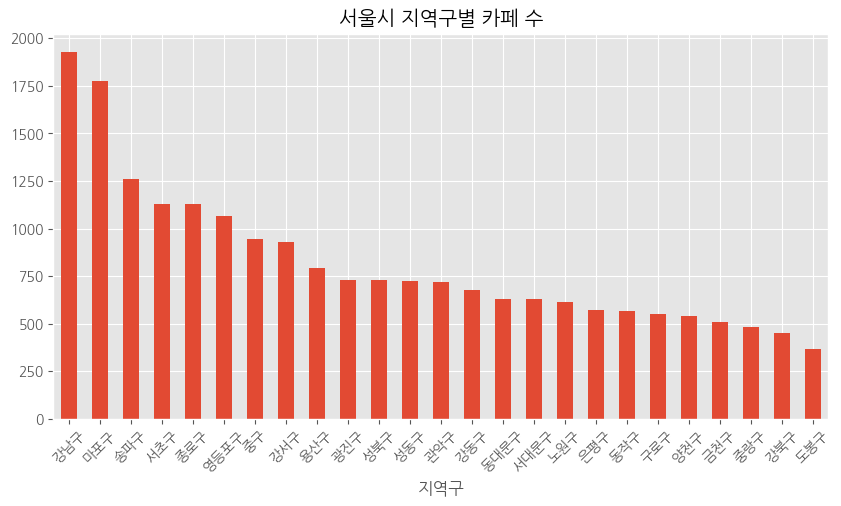

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.style.use('ggplot')
fig, ax = plt.subplots(1,1, figsize=(10, 5))
ax.set_title("서울시 지역구별 카페 수")
서울지역구.plot(kind='bar', ax=ax)
plt.xticks(rotation=45)
plt.show()




In [ ]:
서울지역구 = 서울카페.지역구.value_counts(normalize=False)

In [13]:
with open('../data/skorea_municipalities_geo_simple.json', 'r') as f:
    data = f.read()

In [15]:
import json

서울시_행정구역 = json.loads(data)

In [29]:
import folium
map = folium.Map(location=[37.5502, 126.982], zoom_start=11, tiles="cartodb positron")


In [25]:
서울지역구

지역구
강남구     1928
마포구     1775
송파구     1259
서초구     1131
종로구     1128
영등포구    1068
중구       947
강서구      932
용산구      791
광진구      731
성북구      727
성동구      723
관악구      721
강동구      677
동대문구     632
서대문구     632
노원구      614
은평구      570
동작구      567
구로구      553
양천구      539
금천구      507
중랑구      484
강북구      452
도봉구      366
Name: count, dtype: int64

In [26]:
import requests

geo_str = requests.get("https://t1.daumcdn.net/cfile/tistory/272C224C58B4BD540B").json()
geo_str

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'id': '강동구',
   'properties': {'code': '11250',
    'name': '강동구',
    'name_eng': 'Gangdong-gu',
    'base_year': '2013'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.11519584981606, 37.557533180704915],
      [127.16683184366129, 37.57672487388627],
      [127.18408792330152, 37.55814280369575],
      [127.16530984307447, 37.54221851258693],
      [127.14672806823502, 37.51415680680291],
      [127.12123165719615, 37.52528270089],
      [127.1116764203608, 37.540669955324965],
      [127.11519584981606, 37.557533180704915]]]}},
  {'type': 'Feature',
   'id': '송파구',
   'properties': {'code': '11240',
    'name': '송파구',
    'name_eng': 'Songpa-gu',
    'base_year': '2013'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.0690698130372, 37.522279423505026],
      [127.10087519791962, 37.524841220167055],
      [127.1116764203608, 37.540669955324965],
      [127.12123165719615, 37.52528270089

In [41]:
folium.Choropleth(geo_str, data=서울지역구, fill_color='PuRd', key_on = 'feature.id').add_to(map)

map

In [31]:
서울치킨 = 서울상권[서울상권.상권업종소분류명.isin(['카페'])].copy()

In [39]:
서울치킨['지역구'] = 서울카페.도로명주소.apply(lambda x : x.split()[1])
서울치킨.지역구.value_counts(normalize=False)

지역구
강남구     1928
마포구     1775
송파구     1259
서초구     1131
종로구     1128
영등포구    1068
중구       947
강서구      932
용산구      791
광진구      731
성북구      727
성동구      723
관악구      721
강동구      677
동대문구     632
서대문구     632
노원구      614
은평구      570
동작구      567
구로구      553
양천구      539
금천구      507
중랑구      484
강북구      452
도봉구      366
Name: count, dtype: int64

In [42]:

서울치킨 = 서울상권[서울상권.상권업종소분류명.isin(['치킨'])].copy()

서울치킨['지역구'] = 서울치킨.도로명주소.apply(lambda x : x.split()[1])

서울치킨.지역구.value_counts(normalize=True)
map2 = folium.Map(location=[37.5502, 126.982], zoom_start=11, tiles="cartodb positron")
folium.Choropleth(geo_str, data=서울치킨.지역구.value_counts(normalize=True) , fill_color='PuRd', key_on = 'feature.id').add_to(map2)


In [44]:
map2